In [20]:
import glob
import os
import pandas as pd
import json
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6,4)
import numpy as np

# General Helpers / Constants / Plotters

In [21]:
#COLOURS = ["#d6e5f2", "#b1cee6", "#8cb6da", "#679fce", "#4288c2", "#336ea0", "#27557b", "#1e3f5c"]
COLOURS = [
    "#e3eff9",  # very light
    "#cfe1f2",
    "#b7d2ea",
    "#9fc2e1",
    "#87b2d8",
    "#6fa1ce",
    "#568fc1",
    "#3f76a9",
    "#2c5d86",
    "#1b415f"   # darkest
]


In [22]:
NODE_PREDICTION_GRAPHS =  ['ogbn-arxiv', 'ogbn-papers100M', 'ogbn-products', 'reddit']
LINK_PREDICTION_GRAPHS =  ['ogbl-citation2']

## Grouped Bar Plot

The groups are ['orkut', 'reddit']
No
Max Value 1.3333333333333333


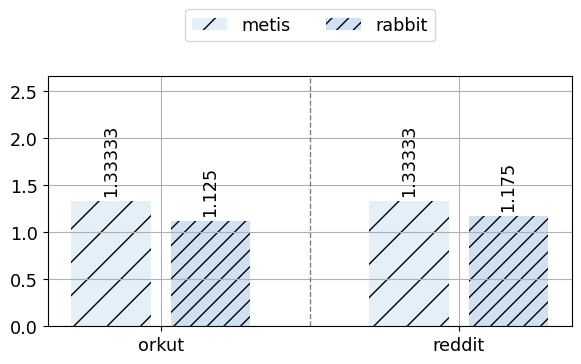

In [23]:
def grouped_bar(group2classes2values, log=False, hline=None, xlabel=None, ylabel=None, numbers=False, save=None, bbox_to_anchor=(0.5, 1.30), y_lim=None, title=None, grid=None,ncol=8,legend=True, default_legend=False, factor_margin=1.0):
    groups = list(group2classes2values.keys())
    print("The groups are", groups)
    try:
        float(groups[0])
        groups_as_int = [int(i) for i in groups]
        groups_as_int.sort()
      #  groups = [str(i) for i in groups_as_int]
    except ValueError:
        print("No")
            
    classes = list(group2classes2values[groups[0]])

    
    hatches =["/", "//", "///", "////", "/////", "//////", "///////"]
    hatches = hatches + ["+", "++", "+++"]
    

    class2color = {}
    for class_index in range(len(classes)):
        class2color[classes[class_index]] = COLOURS[class_index % len(COLOURS)]
    pos = 0
    _, ax = plt.subplots()
    
    max_value = 0
    for group_index in range(len(groups)):
        group = groups[group_index]
        for class_index in range(len(classes)):
            clas = classes[class_index]
            max_value = np.max([max_value, np.mean(group2classes2values[group][clas]) ])
            rects = ax.bar([pos],[np.mean(group2classes2values[group][clas])], hatch=hatches[class_index%len(hatches)], color=class2color[clas])
            if numbers:
                ax.bar_label(rects, padding=3, rotation=90)

            pos += 1
        if(group_index < len(groups)-1 ):
            plt.axvline(x = pos, color = 'gray', linestyle="--", lw=1 )
        pos += 1
    print("Max Value", max_value)
    for class_index in range(len(classes)):
        #plt.plot([], c=class2color[clas], label=clas)
        ax.bar([0],[0], color=class2color[classes[class_index]], label=classes[class_index], hatch=hatches[class_index%len(hatches)] )
        
    first_x_tick =  0
    if len(classes) > 1:
        first_x_tick = len(classes) / 2 - 0.5
    x_ticks = [first_x_tick]
    for i in range(1, len(groups)):
        x_ticks.append(x_ticks[-1]+len(classes)+1)
    plt.xticks(x_ticks, groups, rotation=0)    
    if not hline is None:   
        plt.axhline(y = hline, color = 'red', linestyle="--", lw=1, label="Random")
    if log:
        ax.set_yscale("log")  # Set y-axis to logarithmic scale

    if not xlabel is None:
        plt.xlabel(xlabel=xlabel)
    if not ylabel is None:
        plt.ylabel(ylabel=ylabel)
    if not title is None:
        plt.title(title)
    if not grid is None:
        plt.grid(True, which='both')

    if legend:
        plt.legend(loc='upper center', bbox_to_anchor=bbox_to_anchor, shadow=False, ncol=ncol)
    if default_legend:
        plt.legend(loc='upper left')
    
    #if factor_margin < 1.001:
    plt.tight_layout()
    plt.grid()
 
   
    if y_lim is None:
        ax.set_ylim(0, max_value*factor_margin)
        #ax.set_ylim(0,y_lim)
       # ax.set_ylim(top=ax.get_ylim()[1] * 1.3)
    if not save is None:
       # plt.savefig(f"{save}.pdf", bbox_inches='tight')
        plt.savefig(f"{save}.pdf")

    plt.show()

example = {
    "orkut": {
        "metis": [1.2, 1.3, 1.5],
        "rabbit": [1.1, 1.15]
    },
    "reddit": {
        "metis": [1.2, 1.3, 1.5],
        "rabbit": [1.1, 1.25]
    }
}
grouped_bar(example, numbers=True, factor_margin=2)

# 1. Partitioning Quality
## 1.1 Load Partitioning Data

In [24]:
def get_partitioning_data_fn(file_names):
    data = []
    for file_name in file_names: 
        with open(file_name, 'r') as file:
            json_obj = json.load(file)
            if not "partitioner" in json_obj:
                json_obj["partitioner"] = json_obj["strategy"]
            if "graph_name" in json_obj:
                json_obj["graph"] = json_obj["graph_name"]
            data.append(json_obj)    
    df_python = pd.DataFrame(data)
    #print(df_python.graph.unique())
    df_python = df_python[df_python.graph.isin(['ogbn-products','ogbn-arxiv', 'reddit', 'ogbn-papers100M'])]
    print(df_python.graph.unique())
    
    df_python["partitioner"] = df_python["partitioner"].replace({
        "metis": "Metis",
        "ldg": "LDG",
        "spinner": "SPINNER",
        "directed.cuttana.cuttana256": "CUTTANA"
    })


    
    
    df_our = df_python.copy()
    df_our = df_our[df_our.partitioner == "k-means"]

    df_our["num_layers"] = pd.to_numeric(df_our["num_layers"], errors="coerce").fillna(-1).astype(int)
    df_our["hidden_dims"] = pd.to_numeric(df_our["hidden_dims"], errors="coerce").fillna(-1).astype(int)
    df_our["out_size"] = pd.to_numeric(df_our["out_size"], errors="coerce").fillna(16).astype(int)  # keep your 16 default
    df_our["epochs"] = pd.to_numeric(df_our["epochs"], errors="coerce").fillna(-1).astype(int)


#    df_our["num_layers"] = df_our["num_layers"].astype(int)
 #   df_our["hidden_dims"] = df_our["hidden_dims"].astype(int)
  #  df_our["out_size"] = pd.to_numeric(df_our["out_size"], errors="coerce").fillna(16).astype(int)
   # df_our["epochs"] = df_our["epochs"].astype(int)
    df_our["is_dynamic"] = df_our["dataset_to_partition"] != df_our["dataset"] 
    df_our["dynamic_size"] = df_our["dataset"].str.extract(r"[-_](\d+\.\d+)$").astype(float).where(df_our["is_dynamic"], 1.0)
    df_our["partitioner"] = (
        "GNNPart_" 
        + "M" + df_our["model_name"].astype(str) + "_"
        + "L" + df_our["num_layers"].astype(str) + "_" 
        + "H" + df_our["hidden_dims"].astype(str) + "_" 
        + "E" + df_our["epochs"].astype(str) + "_" 
        + "O" + df_our["out_size"].astype(str) + "_" 
        + df_our["dynamic_size"].astype(str)
    )
    df_our = df_our[df_our["hidden_dims"]==64]
    df_our = df_our[df_our["out_size"]==16]
    
    df_GNNPartDefault = df_our[(df_our["is_dynamic"] == False) & (df_our["epochs"] == 50)]
    df_GNNPartDefault = df_GNNPartDefault[["graph", "num_parts", "edge_cut", "balance","train_balance", "partitioning_time", "partitioner"]]


    df_GNNPartDefault.loc[df_GNNPartDefault['partitioner'].str.contains('GNNPart_Mgraphsage_L3_H64_E50_O16_1.0', regex=False), 'partitioner'] = 'EmbedPart-V-3'
    df_GNNPartDefault.loc[df_GNNPartDefault['partitioner'].str.contains('GNNPart_Mgraphsage_L2_H64_E50_O16_1.0', regex=False), 'partitioner'] = 'EmbedPart-V-2'
    df_GNNPartDefault.loc[df_GNNPartDefault['partitioner'].str.contains('GNNPart_Mlinkgraphsage_L3_H64_E50_O16_1.0', regex=False), 'partitioner'] = 'EmbedPart-L-3'
    df_GNNPartDefault.loc[df_GNNPartDefault['partitioner'].str.contains('GNNPart_Mlinkgraphsage_L2_H64_E50_O16_1.0', regex=False), 'partitioner'] = 'EmbedPart-L-2'



    baselines_df = df_python.copy()
    baselines_df = baselines_df[baselines_df.partitioner.isin(['Metis', 'random', "SPINNER", "LDG", "CUTTANA"])]
    feature_partitioning_df = baselines_df[baselines_df.partitioner.isin(["feature-partitioning"])]
    baselines_df.loc[baselines_df['partitioner'].isin(['SPINNER', 'LDG']), 'partitioning_time'] /= 1000
    
    baselines_df = baselines_df[["graph", "num_parts", "edge_cut", "balance","train_balance", "partitioning_time", "partitioner"]]


    metis_times = pd.read_csv("../results/partitioning-metrics/metis-raw-times/partitioning_times.csv")
    metis_times["partitioner"] = "Metis"
    keys = ["graph", "partitioner", "num_parts"]
    # only bring over METIS rows from `new`
    new_metis = (
        metis_times.loc[metis_times["partitioner"] == "Metis", keys + ["partitioning_time"]]
           .rename(columns={"partitioning_time": "partitioning_time_new"})
    )
    tmp = baselines_df.merge(new_metis, on=keys, how="left")
    mask = (tmp["partitioner"] == "Metis") & tmp["partitioning_time_new"].notna()
    tmp.loc[mask, "partitioning_time"] = tmp.loc[mask, "partitioning_time_new"]
    baselines_df = tmp.drop(columns=["partitioning_time_new"])




    # cuttana

    
    cuttana_times = pd.read_csv("../results/partitioning-metrics/cuttana/cuttana_partitioning_runtime.csv")
    cuttana_times["partitioner"] = "CUTTANA"
    keys = ["graph", "partitioner", "num_parts"]
    # only bring over Cuttana rows from `new`
    new_cuttana = (
        cuttana_times.loc[cuttana_times["partitioner"] == "CUTTANA", keys + ["partitioning_time"]]
           .rename(columns={"partitioning_time": "partitioning_time_new"})
    )
    tmp = baselines_df.merge(new_cuttana, on=keys, how="left")
    mask = (tmp["partitioner"] == "CUTTANA") & tmp["partitioning_time_new"].notna()
    tmp.loc[mask, "partitioning_time"] = tmp.loc[mask, "partitioning_time_new"]
    baselines_df = tmp.drop(columns=["partitioning_time_new"])

    df_python = df_python[df_python.graph.isin(['ogbn-products','ogbn-arxiv', 'reddit', 'ogbn-papers100M'])]

    
    
    
    
    return df_our, df_GNNPartDefault,baselines_df,feature_partitioning_df


partitioning_metric_files = [
    "../results/partitioning-metrics/cpp/*.json", # spinner and ldg, cuttana
    "../results/partitioning-metrics/random-metis/*.json", # metis and random
    
    "../results/partitioning-metrics-fast/2025-09-17_18-58-17/*.json", # 50 epochs
    "../results/partitioning-metrics-fast/2025-09-21_18-59-13/*.json", # all but 50 epochs
    "../results/partitioning-metrics-fast/2025-09-22_19-23-19/*.json", # feature partitioning
    "../results/partitioning-metrics-fast/2025-09-22_20-14-58/*.json", # robustness experiments
]

partitioning_metric_file_names = [] 
for mf in partitioning_metric_files:
    partitioning_metric_file_names += glob.glob(mf)
    
our_partitioning, our_partitioning_default, baselines_partitioning, feature_partitioning_df = get_partitioning_data_fn(partitioning_metric_file_names)

['ogbn-products' 'ogbn-arxiv' 'reddit' 'ogbn-papers100M']


## 1.15 Graph Metrics

In [27]:
graph_overview = our_partitioning[(our_partitioning.partitioner == "GNNPart_Mlinkgraphsage_L3_H64_E10_O16_1.0") & (our_partitioning.num_parts==2)]
#graph_overview

In [28]:
graph_overview = our_partitioning[(our_partitioning.partitioner == "GNNPart_Mlinkgraphsage_L3_H64_E10_O16_1.0") & (our_partitioning.num_parts==2)]
graph_overview = graph_overview[["dataset", "num_nodes", "num_edges"]]
graph_overview["Mean Degree"] = (graph_overview["num_edges"]*2)/graph_overview["num_nodes"]
print(graph_overview.sort_values(by="num_edges").to_latex(index=False, escape=False,column_format="llS[table-format=1.2]S[table-format=1.2]S[table-format=1.2]",
    float_format="%.2f"))

\begin{tabular}{llS[table-format=1.2]S[table-format=1.2]S[table-format=1.2]}
\toprule
        dataset &  num_nodes &  num_edges &  Mean Degree \\
\midrule
     ogbn-arxiv &     169343 &    1166243 &        13.77 \\
         reddit &     232965 &  114615892 &       983.98 \\
  ogbn-products &    2449029 &  123718280 &       101.03 \\
ogbn-papers100M &  111059956 & 1615685872 &        29.10 \\
\bottomrule
\end{tabular}



/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/567776534.py:4: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(graph_overview.sort_values(by="num_edges").to_latex(index=False, escape=False,column_format="llS[table-format=1.2]S[table-format=1.2]S[table-format=1.2]",


## 1.2 Partitioning Quality with default parameters

In [29]:
overview_partitioning_quality_default = pd.concat([our_partitioning_default,baselines_partitioning ])
overview_partitioning_quality_default = overview_partitioning_quality_default.sort_values(by=["graph","num_parts","edge_cut"])[["graph", "num_parts", "edge_cut","train_balance","partitioning_time", "partitioner"]]
overview_partitioning_quality_default["partitioning_time"] = overview_partitioning_quality_default["partitioning_time"].round(3)
overview_partitioning_quality_default["edge_cut"] = overview_partitioning_quality_default["edge_cut"].round(3)
overview_partitioning_quality_default["train_balance"] = overview_partitioning_quality_default["train_balance"].round(3)

### 1.2.1 Edge Cut Ratio

In [33]:
import pandas as pd

# Assume df is your DataFrame
# Target and baseline methods
#target = "GNNPart-L-3"
for target in ["EmbedPart-L-3", "EmbedPart-L-2", "EmbedPart-V-3", "EmbedPart-V-3"]:
    for baseline in ["Metis","SPINNER","LDG", "CUTTANA"]: 
        # Collect case-level comparisons
        comparisons = []
        
        for (graph, num_parts), group in overview_partitioning_quality_default.groupby(["graph", "num_parts"]):
            target_row = group[group["partitioner"] == target]
            baseline_row = group[group["partitioner"] == baseline]
            
            if target_row.empty or baseline_row.empty:
                continue  # skip if one is missing
        
            t_time = target_row["edge_cut"].values[0]
            b_time = baseline_row["edge_cut"].values[0]
        
            comparisons.append({
                "graph": graph,
                "num_parts": num_parts,
                "target_time": t_time,
                "baseline_time": b_time,
                "is_target_better": t_time < b_time
            })
        
        # Create a comparison DataFrame
        compare_df = pd.DataFrame(comparisons)
        
        # Compute aggregate statistics
        percent_better = 100 * compare_df["is_target_better"].mean()
        num_cases = len(compare_df)
        
        print(f"{target} better edge cut than {baseline} in {percent_better:.1f}% of {num_cases} cases.")
    

EmbedPart-L-3 better edge cut than Metis in 25.0% of 20 cases.
EmbedPart-L-3 better edge cut than SPINNER in 50.0% of 20 cases.
EmbedPart-L-3 better edge cut than LDG in 100.0% of 20 cases.
EmbedPart-L-3 better edge cut than CUTTANA in 80.0% of 20 cases.
EmbedPart-L-2 better edge cut than Metis in 15.0% of 20 cases.
EmbedPart-L-2 better edge cut than SPINNER in 35.0% of 20 cases.
EmbedPart-L-2 better edge cut than LDG in 90.0% of 20 cases.
EmbedPart-L-2 better edge cut than CUTTANA in 70.0% of 20 cases.
EmbedPart-V-3 better edge cut than Metis in 15.0% of 20 cases.
EmbedPart-V-3 better edge cut than SPINNER in 35.0% of 20 cases.
EmbedPart-V-3 better edge cut than LDG in 80.0% of 20 cases.
EmbedPart-V-3 better edge cut than CUTTANA in 40.0% of 20 cases.
EmbedPart-V-3 better edge cut than Metis in 15.0% of 20 cases.
EmbedPart-V-3 better edge cut than SPINNER in 35.0% of 20 cases.
EmbedPart-V-3 better edge cut than LDG in 80.0% of 20 cases.
EmbedPart-V-3 better edge cut than CUTTANA in 40

In [96]:
b = overview_partitioning_quality_default[overview_partitioning_quality_default['partitioner'] == 'random'][['graph', 'num_parts', 'edge_cut', 'partitioning_time']]
b = b.rename(columns={
    'edge_cut': 'random_edge_cut'
})

# Merge the baseline values into the original dataframe
df_normalized = overview_partitioning_quality_default.merge(b, on=['graph', 'num_parts'], how='left')

# Normalize edge_cut and partitioning_time relative to "random"
# Compute percentage reduction relative to 'random'
df_normalized['edge_cut_reduction_pct'] = (1 - df_normalized['edge_cut'] / df_normalized['random_edge_cut']) * 100
# Optional: drop the extra columns if you don't need them
#df_normalized = df_normalized.drop(columns=['random_edge_cut', 'random_partitioning_time'])

#df_filtered = df_normalized[df_normalized['partitioner'] != 'random']

means = df_normalized.groupby('partitioner')['edge_cut_reduction_pct'].mean().sort_values(ascending=False)
print(means)


df_filtered = df_normalized[~df_normalized.partitioner.isin(["random"])]

# Show the result

partitioner
Metis            74.648867
SPINNER          69.806673
EmbedPart-L-3    67.708459
EmbedPart-L-2    67.137099
EmbedPart-V-3    58.993373
EmbedPart-V-2    57.485873
CUTTANA          56.463983
LDG              42.135741
random            0.000000
Name: edge_cut_reduction_pct, dtype: float64


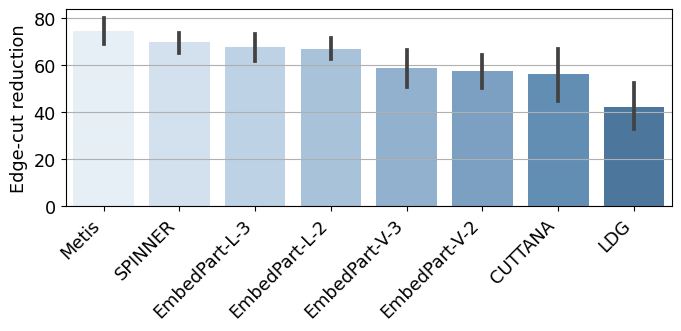

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
order = df_filtered.groupby('partitioner')['edge_cut_reduction_pct'].mean().sort_values(ascending=False).index

plt.figure(figsize=(7, 3.5))
sns.barplot(
    data=df_filtered,
    x='partitioner',
    y='edge_cut_reduction_pct',
    estimator='mean',
    errorbar=('ci', 95),
    order=order,
    palette=COLOURS[:len(order)]  # safe slicing

)

plt.xticks(rotation=45, ha='right')  # rotate x labels
#plt.ylabel('Edge-cut reduction in (%) of random')
plt.ylabel('Edge-cut reduction')
plt.xlabel('')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("plots/partitioning-metrics/edge-cut-distribution-barplot.pdf", dpi=300, bbox_inches='tight')

plt.show()

/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/587869045.py:1: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for i, d in overview_partitioning_quality_default.groupby(by=["graph"]):


### GRAPH: ogbn-arxiv ###
The groups are [2, 4, 8, 16, 32]
Max Value 0.969


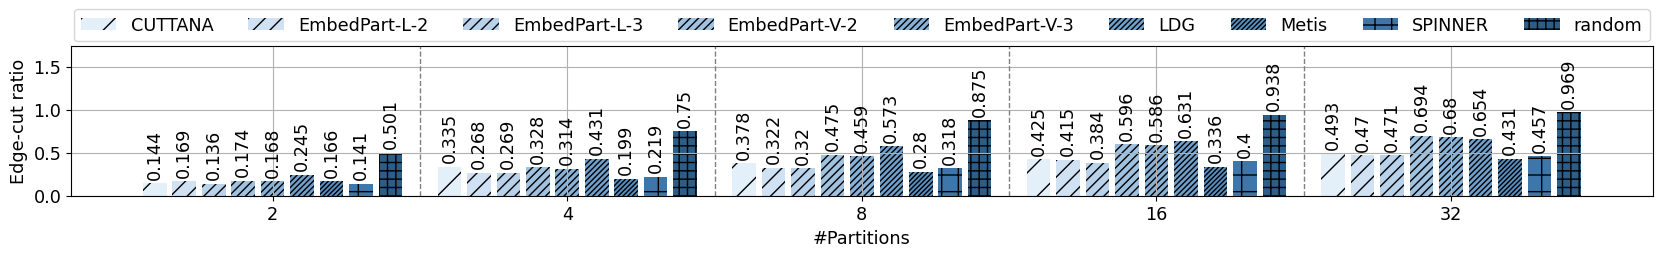

### GRAPH: ogbn-papers100M ###
The groups are [2, 4, 8, 16, 32]
Max Value 0.969


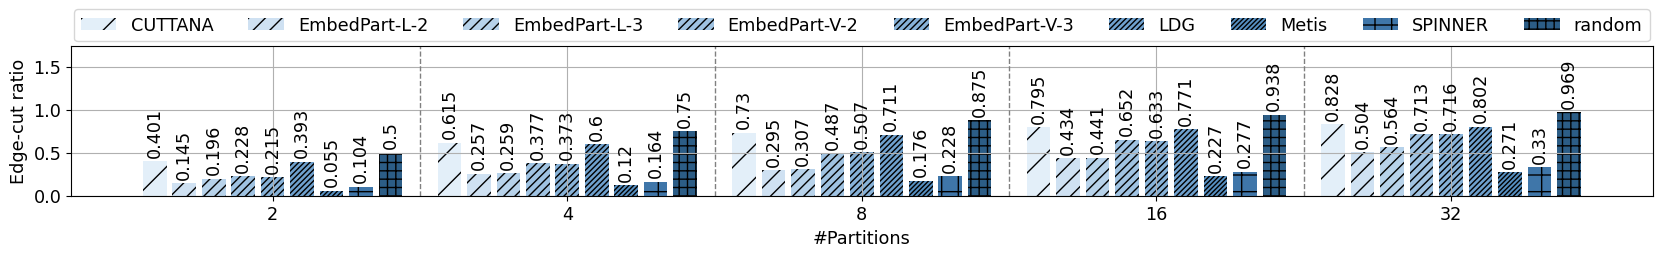

### GRAPH: ogbn-products ###
The groups are [2, 4, 8, 16, 32]
Max Value 0.969


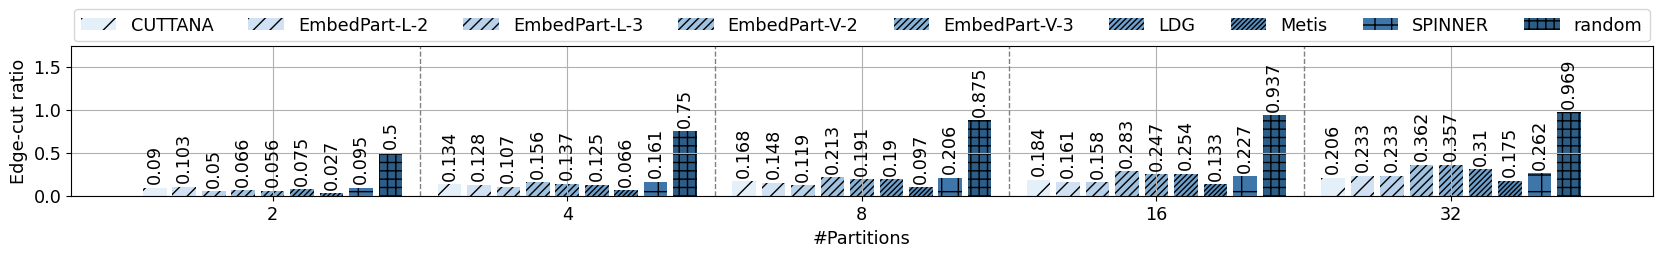

### GRAPH: reddit ###
The groups are [2, 4, 8, 16, 32]
Max Value 0.969


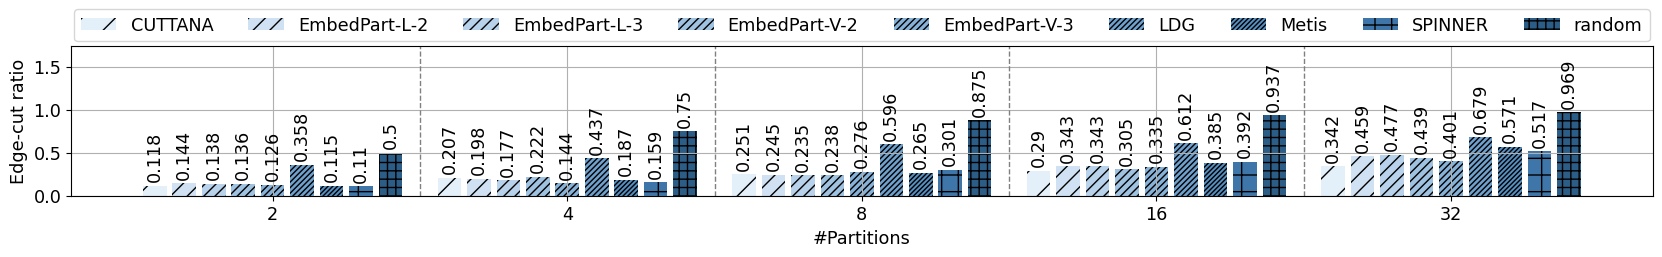

In [38]:
for i, d in overview_partitioning_quality_default.groupby(by=["graph"]):
    print(f"### GRAPH: {i} ###")
    nested_dict = (
        d.groupby(['num_parts', 'partitioner'])['edge_cut']
        .apply(list)
        .unstack()
        .to_dict(orient='index')
    )
   # print(nested_dict)
    # 8/2.8= 
    plt.rcParams["figure.figsize"] = (8,2.4)
    plt.rcParams["figure.figsize"] = (12,4)

    plt.rcParams["figure.figsize"] = (18,3)
    plt.rcParams["font.size"] = 12.7
    
    grouped_bar(nested_dict,save=f"plots/partitioning-metrics/edge-cut-ratio-{i}", numbers=True, xlabel="#Partitions", ylabel="Edge-cut ratio",ncol=9, factor_margin=1.8)

    

### 1.2.2 Training Vertex Balance

/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/1331563315.py:1: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for i, d in overview_partitioning_quality_default.groupby(by=["graph"]):


### GRAPH: ogbn-arxiv ###
The groups are [2, 4, 8, 16, 32]
Max Value 2.011


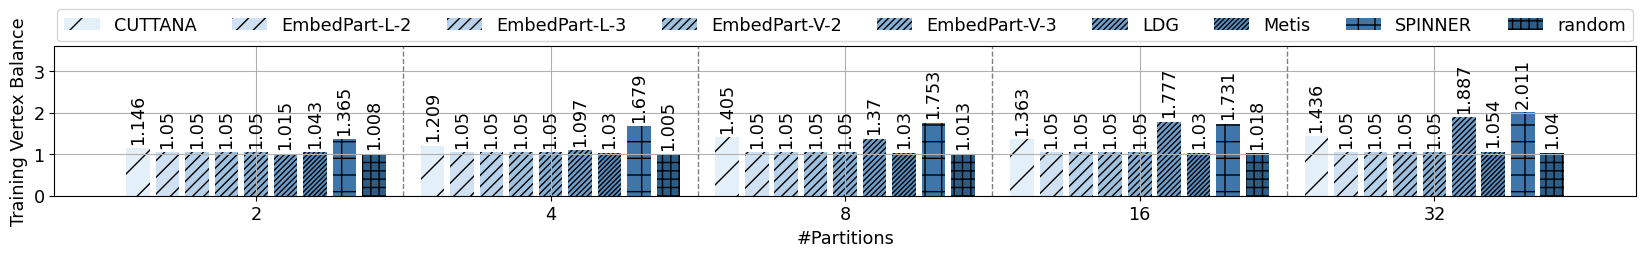

### GRAPH: ogbn-papers100M ###
The groups are [2, 4, 8, 16, 32]
Max Value 4.936


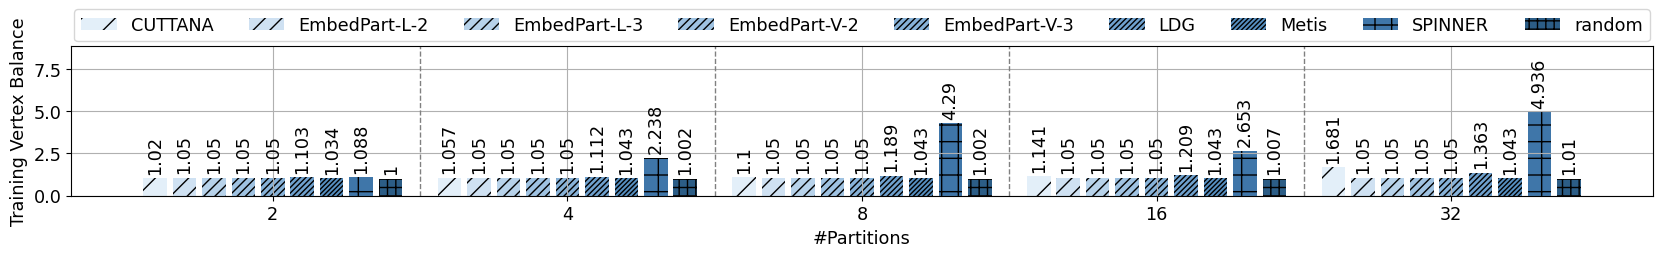

### GRAPH: ogbn-products ###
The groups are [2, 4, 8, 16, 32]
Max Value 3.468


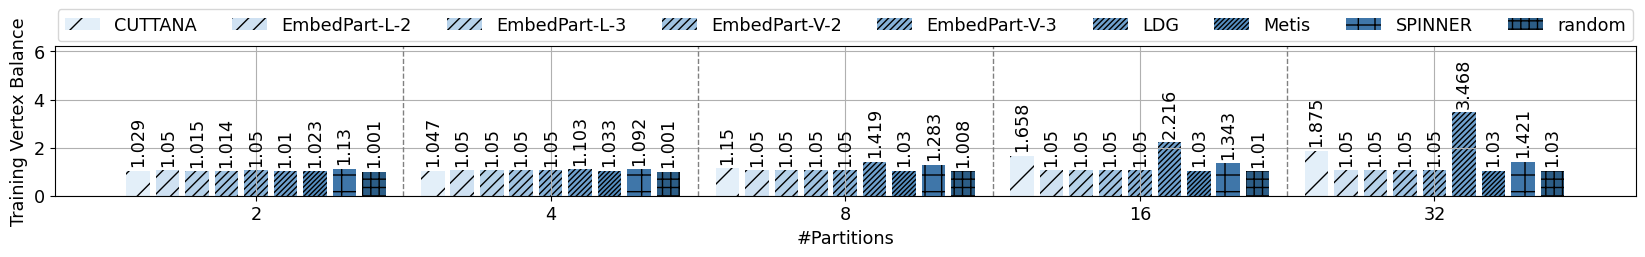

### GRAPH: reddit ###
The groups are [2, 4, 8, 16, 32]
Max Value 2.631


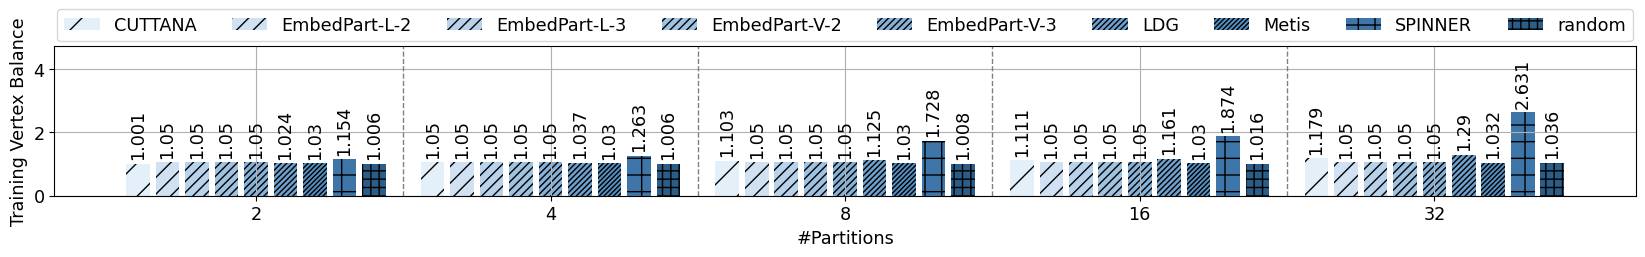

In [39]:
for i, d in overview_partitioning_quality_default.groupby(by=["graph"]):
    if i in NODE_PREDICTION_GRAPHS:
        print(f"### GRAPH: {i} ###")
        nested_dict = (
            d.groupby(['num_parts', 'partitioner'])['train_balance']
            .apply(list)
            .unstack()
            .to_dict(orient='index')
        )
       # print(nested_dict)
        # 8/2.8= 

        plt.rcParams["figure.figsize"] = (16,2.5)
        plt.rcParams["font.size"] = 11.5
        plt.rcParams["figure.figsize"] = (18,3)
        plt.rcParams["font.size"] = 12.7
    
        grouped_bar(nested_dict,save=f"plots/partitioning-metrics/training-vertex-balance-{i}", numbers=True, xlabel="#Partitions", ylabel="Training Vertex Balance",ncol=9, factor_margin=1.8)
       

### 1.2.3 Partitioning Time

partitioner
CUTTANA            1.783782
EmbedPart-L-2    155.268235
EmbedPart-L-3    152.893177
EmbedPart-V-2    127.124925
EmbedPart-V-3    130.604133
LDG               61.102100
Metis              1.000000
SPINNER            0.713034
Name: partitioning_speedup_vs_metis, dtype: float64


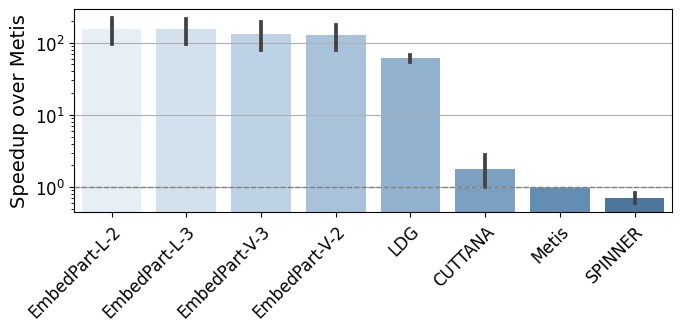

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


baseline = overview_partitioning_quality_default[
    overview_partitioning_quality_default['partitioner'] == 'Metis'
][['graph', 'num_parts', 'partitioning_time']]
baseline = baseline.rename(columns={'partitioning_time': 'metis_partitioning_time'})


df_normalized = overview_partitioning_quality_default.merge(
    baseline, on=['graph', 'num_parts'], how='left'
)


df_normalized['partitioning_speedup_vs_metis'] = (
    df_normalized['metis_partitioning_time'] / df_normalized['partitioning_time']
)


df_filtered = df_normalized[df_normalized['partitioner'] != 'random']


means = df_filtered.groupby('partitioner')['partitioning_speedup_vs_metis'].mean()
sorted_partitioners = means.sort_values(ascending=False).index.tolist()
print(means)
palette = sns.color_palette("colorblind", len(sorted_partitioners))
# Step 6: Bar plot (mean + 95% CI)
plt.figure(figsize=(7, 3.5))
sns.barplot(
    data=df_filtered,
    x='partitioner',
    y='partitioning_speedup_vs_metis',
    estimator='mean',
    errorbar=('ci', 95),
    order=sorted_partitioners,
    palette=COLOURS[:len(sorted_partitioners)]  # safe slicing


)

# Log scale + baseline
plt.yscale('log')
plt.axhline(1, color='gray', linestyle='--', linewidth=1)

# Formatting
#plt.ylabel('Speedup over Metis (log scale)', fontsize=14)
plt.ylabel('Speedup over Metis', fontsize=14)
plt.xlabel('')
plt.xticks(rotation=45, ha='right', rotation_mode='anchor', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y')
plt.tight_layout()

plt.savefig(
    "plots/partitioning-metrics/partitioning-time-barplot.pdf",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/75798695.py:3: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for i, d in overview_partitioning_quality_default.groupby(by=["graph"]):


### GRAPH: ogbn-arxiv ###
The groups are [2, 4, 8, 16, 32]
Max Value 1.381


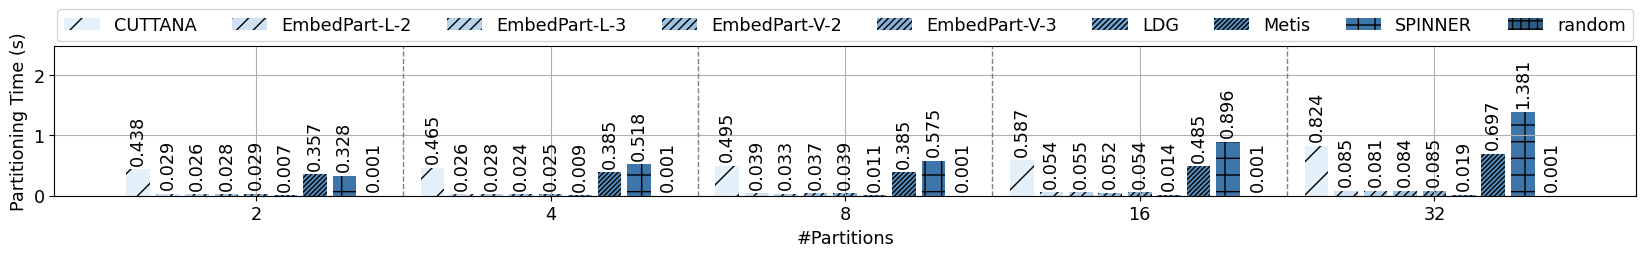

### GRAPH: ogbn-papers100M ###
The groups are [2, 4, 8, 16, 32]
Max Value 4608.42


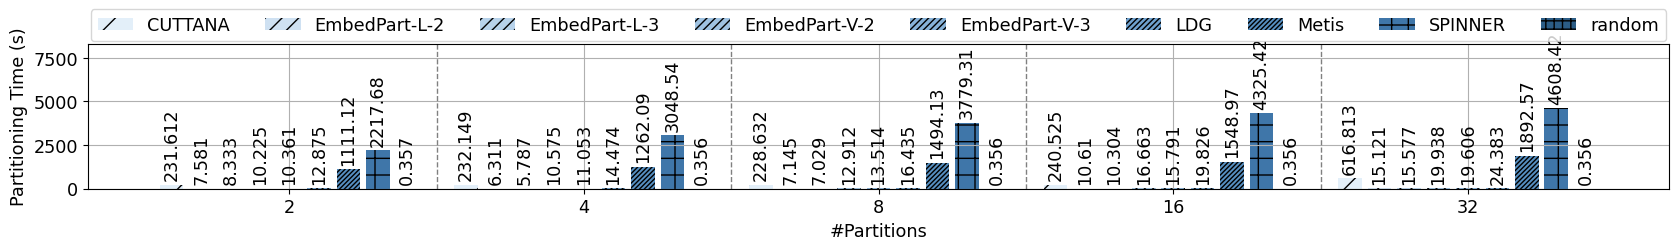

### GRAPH: ogbn-products ###
The groups are [2, 4, 8, 16, 32]
Max Value 55.066


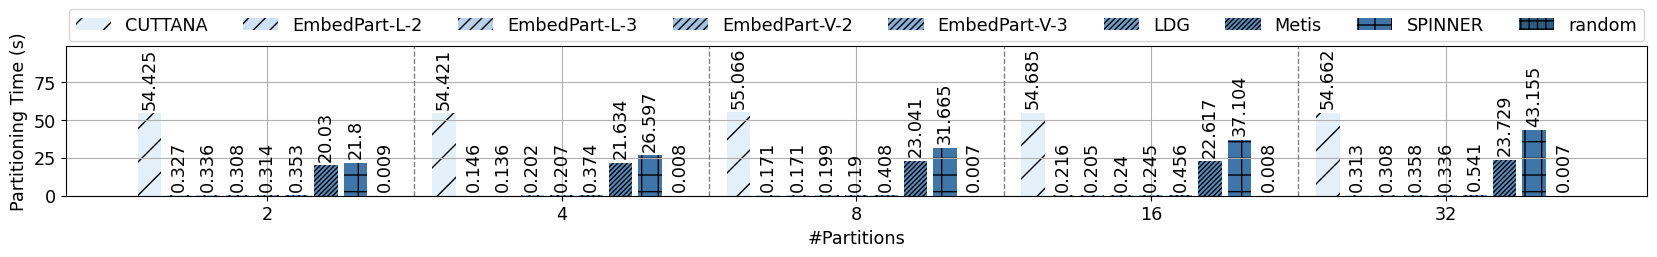

### GRAPH: reddit ###
The groups are [2, 4, 8, 16, 32]
Max Value 27.528


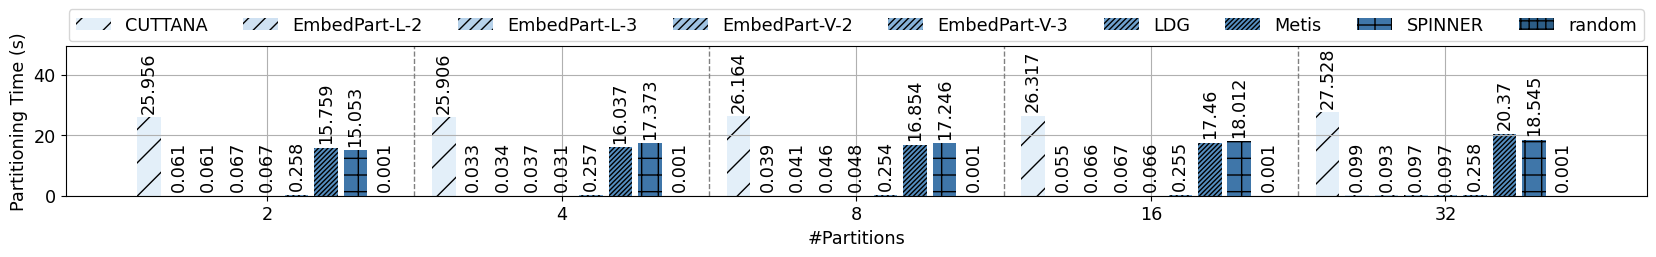

In [42]:

overview_partitioning_quality_default["partitioning_time"] = overview_partitioning_quality_default["partitioning_time"].round(3)

for i, d in overview_partitioning_quality_default.groupby(by=["graph"]):
    print(f"### GRAPH: {i} ###")
    nested_dict = (
        d.groupby(['num_parts', 'partitioner'])['partitioning_time']
        .apply(list)
        .unstack()
        .to_dict(orient='index')
    )
   # print(nested_dict)
    plt.rcParams["figure.figsize"] = (8,2.4)
    plt.rcParams["figure.figsize"] = (12,4)
    plt.rcParams["figure.figsize"] = (12,3)

    plt.rcParams["figure.figsize"] = (16,2.5)
    plt.rcParams["font.size"] = 11.5
    plt.rcParams["figure.figsize"] = (18,3)
    plt.rcParams["font.size"] = 12.7



    grouped_bar(nested_dict, save=f"plots/partitioning-metrics/partitioning-time-{i}", numbers=True, xlabel="#Partitions", ylabel="Partitioning Time (s)", ncol=9, factor_margin=1.8,)
    
    
    

#### 1.2.3.1 Average Partitioning Time speedups compared to Baseline (table; we mentions these numbers in the paper)

In [43]:
df_pivoted = overview_partitioning_quality_default.pivot(
    index=["graph", "num_parts"],
    columns="partitioner",
    values="partitioning_time"
).reset_index()

for p in ["LDG", "Metis", "SPINNER", "CUTTANA", "EmbedPart-L-2", "EmbedPart-V-2", "EmbedPart-V-3"]:
    df_pivoted[f"speedup_GNNPart-V-2_{p}"] = df_pivoted[p] /  df_pivoted["EmbedPart-V-2"]
    df_pivoted[f"speedup_GNNPart-V-3_{p}"] = df_pivoted[p] /  df_pivoted["EmbedPart-V-3"]
    df_pivoted[f"speedup_GNNPart-L-2_{p}"] = df_pivoted[p] /  df_pivoted["EmbedPart-L-2"]
    df_pivoted[f"speedup_GNNPart-L-3_{p}"] = df_pivoted[p] /  df_pivoted["EmbedPart-L-3"]
    df_pivoted[f"speedup_{p}_metis"] = df_pivoted["Metis"] /  df_pivoted[p]
    
print(df_pivoted.mean().round(2))

###### Only focus on the rows with speedup ######
###### Only focus on the rows with speedup ######
###### Only focus on the rows with speedup ######
partitioner
num_parts                             12.40
CUTTANA                               97.88
EmbedPart-L-2                          2.42
EmbedPart-L-3                          2.44
EmbedPart-V-2                          3.61
EmbedPart-V-3                          3.61
LDG                                    4.57
Metis                                375.44
SPINNER                              911.48
random                                 0.09
speedup_GNNPart-V-2_LDG                1.95
speedup_GNNPart-V-3_LDG                2.01
speedup_GNNPart-L-2_LDG                2.34
speedup_GNNPart-L-3_LDG                2.30
speedup_LDG_metis                     61.10
speedup_GNNPart-V-2_Metis            127.12
speedup_GNNPart-V-3_Metis            130.60
speedup_GNNPart-L-2_Metis            155.27
speedup_GNNPart-L-3_Metis            152.89
sp

/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/1317558137.py:20: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(df_pivoted.mean().round(2))


## Deep Dive -- Our approach

### Embedding Quality versus Number of Training Epochs
#### 0 Epochs

In [45]:
random_partitioning_metrics = baselines_partitioning[baselines_partitioning.partitioner == "random"]

random_partitioning_metrics = random_partitioning_metrics[random_partitioning_metrics.graph.isin(["ogbn-arxiv","ogbn-papers100M", "ogbn-products", "reddit"])] 


random_partitioning_metrics= random_partitioning_metrics.sort_values(by=["graph", "num_parts"])[
    ["graph", "num_parts", "edge_cut", "partitioner"]
]
our_partitioning_epoch_experiments = our_partitioning[our_partitioning.is_dynamic == False]

#print(our_partitioning_epoch_experiments.partitioner.unique())
# which model

random_proj = our_partitioning_epoch_experiments[
    ["graph","partitioner", "edge_cut","num_parts", "num_layers", "epochs"]
].sort_values(by=["graph", "num_parts", "epochs"])

#random_proj["partitioner"] = "random-GNN"

random_proj["partitioner"] = random_proj["partitioner"].apply(
    lambda x: "EmbedPart-L" if "linkgraphsage" in x else "EmbedPart-V"
)

random_proj = random_proj[random_proj.epochs == 0].groupby(by=[
    "graph","partitioner", "num_parts","epochs"], as_index=False).mean()[
    ["graph", "num_parts", "edge_cut", "partitioner"]
]

merged_epoch_random_pro_exp = pd.merge(random_proj,random_partitioning_metrics, on=["graph", "num_parts"])
#merged_epoch_random_pro_exp

In [47]:

merged_epoch_random_pro_exp["edge_cut_reduction_%"] = (merged_epoch_random_pro_exp["edge_cut_y"] - merged_epoch_random_pro_exp["edge_cut_x"]) / merged_epoch_random_pro_exp["edge_cut_y"] * 100
#merged_epoch_random_pro_exp[["partitioner_x", "edge_cut_reduction_%","num_parts", "graph"]]





In [49]:
for i, d in merged_epoch_random_pro_exp.groupby(by=["partitioner_x"]):
    print(i)
    pivot_merged_epoch_random_pro_exp = d.pivot(index='num_parts', columns='graph', values='edge_cut_reduction_%').reset_index()
    pivot_merged_epoch_random_pro_exp.columns.name = None  # remove the hierarchical column name
    pivot_merged_epoch_random_pro_exp = pivot_merged_epoch_random_pro_exp.round(2)
    pivot_merged_epoch_random_pro_exp.round(2).mean().round(2)
    print(pivot_merged_epoch_random_pro_exp.round(2).mean().round(2))
    print(pivot_merged_epoch_random_pro_exp.to_latex(index=False, float_format="%.2f", caption="Edge-cut values for different datasets and dynamic sizes", label="tab:edgecut"))


EmbedPart-L
num_parts          12.40
ogbn-arxiv         25.17
ogbn-papers100M    39.50
ogbn-products      33.89
reddit             14.84
dtype: float64
\begin{table}
\centering
\caption{Edge-cut values for different datasets and dynamic sizes}
\label{tab:edgecut}
\begin{tabular}{rrrrr}
\toprule
 num\_parts &  ogbn-arxiv &  ogbn-papers100M &  ogbn-products &  reddit \\
\midrule
         2 &       32.89 &            52.76 &          48.74 &   29.59 \\
         4 &       31.05 &            53.40 &          37.20 &   15.60 \\
         8 &       26.37 &            40.04 &          32.10 &   11.08 \\
        16 &       20.25 &            28.45 &          27.75 &    9.48 \\
        32 &       15.29 &            22.83 &          23.67 &    8.44 \\
\bottomrule
\end{tabular}
\end{table}

EmbedPart-V
num_parts          12.40
ogbn-arxiv         11.13
ogbn-papers100M    32.36
ogbn-products      31.23
reddit             14.17
dtype: float64
\begin{table}
\centering
\caption{Edge-cut values for diffe

/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/1603390772.py:1: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for i, d in merged_epoch_random_pro_exp.groupby(by=["partitioner_x"]):
/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/1603390772.py:8: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(pivot_merged_epoch_random_pro_exp.to_latex(index=False, float_format="%.2f", caption="Edge-cut values for different datasets and dynamic sizes", label="tab:edgecut"))
/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822

#### Epochs [0-90]

In [50]:

df_epoch_experiments = our_partitioning[our_partitioning.is_dynamic == False]


In [51]:
for i, d in df_epoch_experiments.groupby(by="model_name"):
    print(i)
    r = d[["dataset_to_partition", "epochs", "edge_cut"]].groupby(by=["dataset_to_partition", "epochs"],as_index=False).mean()
    pivot_r = r.pivot(index='epochs', columns='dataset_to_partition', values='edge_cut').reset_index()
    pivot_r.columns.name = None  # remove the hierarchical column name
    pivot_r = pivot_r.round(2)
    latex_table = pivot_r.rename(columns={
        "epochs": "epochs",
        "ogbn-arxiv": "ogbn-arxiv",
        "ogbn-papers100M": "ogbn-papers100M",
        "ogbn-products": "ogbn-products",
        "reddit": "reddit"
    }).to_latex(index=False, float_format="%.2f", caption="Edge-cut values for different datasets and epochs", label="tab:edgecut")
    
    print(latex_table)


graphsage
\begin{table}
\centering
\caption{Edge-cut values for different datasets and epochs}
\label{tab:edgecut}
\begin{tabular}{rrrrr}
\toprule
 epochs &  ogbn-arxiv &  ogbn-papers100M &  ogbn-products &  reddit \\
\midrule
      0 &        0.72 &             0.56 &           0.56 &    0.70 \\
      1 &        0.70 &             0.49 &           0.51 &    0.52 \\
      2 &        0.67 &             0.48 &           0.44 &    0.42 \\
      3 &        0.61 &             0.49 &           0.39 &    0.37 \\
      4 &        0.59 &             0.48 &           0.36 &    0.33 \\
      5 &        0.56 &             0.49 &           0.34 &    0.31 \\
     10 &        0.50 &             0.49 &           0.27 &    0.28 \\
     30 &        0.45 &             0.49 &           0.22 &    0.27 \\
     50 &        0.45 &             0.49 &           0.21 &    0.26 \\
     70 &        0.44 &             0.49 &           0.20 &    0.27 \\
     90 &        0.44 &             0.49 &           0.20 &    

/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/2644451499.py:7: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = pivot_r.rename(columns={
/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/2644451499.py:7: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = pivot_r.rename(columns={


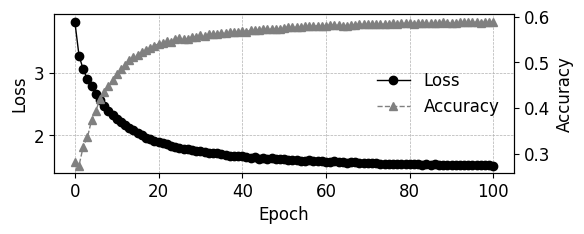

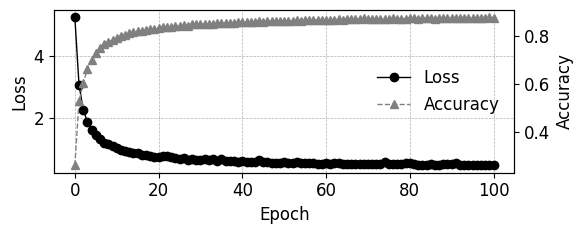

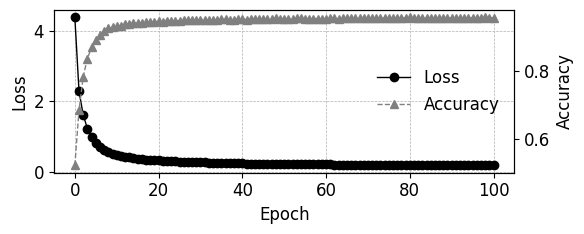

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# SIGMOD/VLDB-style plot config
plt.rcParams.update({
    'font.size': 12,
    'lines.linewidth': 1,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

LOSS_STYLE = {'linestyle': '-',  'marker': 'o', 'color': 'black', 'label': 'Loss'}
ACC_STYLE  = {'linestyle': '--', 'marker': '^', 'color': 'gray',  'label': 'Accuracy'}

for f in [
    "graphsage_ogbn-arxiv_64_2_25_10_metrics", 
#    "graphsage_ogbn-arxiv_64_3_15_10_5_metrics",
    "graphsage_ogbn-products_64_2_25_10_metrics",
 #   "graphsage_ogbn-products_64_3_15_10_5_metrics",
    "graphsage_reddit_64_2_25_10_metrics",
  #  "graphsage_reddit_64_3_15_10_5_metrics",
]:
    ff = f"../results/gnn-partitioner-accuracy/{f}.csv"
    df = pd.read_csv(ff)

    fig, ax1 = plt.subplots(figsize=(6, 2.5))

    # Left y-axis: loss
    line1, = ax1.plot(df['epoch'], df['loss'], **LOSS_STYLE)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='black')
    ax1.tick_params(axis='y', labelcolor='black')

    # Right y-axis: accuracy
    ax2 = ax1.twinx()
    line2, = ax2.plot(df['epoch'], df['accuracy'], **ACC_STYLE)
    ax2.set_ylabel('Accuracy', color='black')
    ax2.tick_params(axis='y', labelcolor='black')

    # Legend inside the plot (e.g., lower left — adjust as needed)
    lines = [line1, line2]
    labels = [line.get_label() for line in lines]
    ax1.legend(
        lines, labels,
        loc='center right',
        bbox_to_anchor=(1.0, 0.5),
        frameon=False
    )

    ax1.grid(True, linestyle='--', linewidth=0.5)
    fig.tight_layout()
    plt.savefig(f'plots/partitioning-metrics/loss_{f}.pdf', bbox_inches='tight')  # or .png
    plt.show()

## Robustness to Graph Updates

In [53]:
df_dynamic_experiments = our_partitioning[our_partitioning.epochs == 50]
#print(df_dynamic_experiments)
df_dynamic_experiments = df_dynamic_experiments[df_dynamic_experiments.model_name=="graphsage"]


In [54]:
r = df_dynamic_experiments[["dataset_to_partition", "dynamic_size", "edge_cut"]].groupby(by=["dataset_to_partition", "dynamic_size"],as_index=False).mean()
pivot_r = r.pivot(index='dynamic_size', columns='dataset_to_partition', values='edge_cut').reset_index()
pivot_r.columns.name = None  # remove the hierarchical column name
pivot_r = pivot_r.round(2)
pivot_r["dynamic_size"] = pivot_r["dynamic_size"]*100
pivot_r["dynamic_size"] = pivot_r["dynamic_size"].astype(int)

In [55]:
latex_table = pivot_r.rename(columns={
    "dynamic_size": "Graph Size",
    "ogbn-arxiv": "ogbn-arxiv",
    "ogbn-papers100M": "ogbn-papers100M",
    "ogbn-products": "ogbn-products",
    "reddit": "reddit"
}).to_latex(index=False, float_format="%.2f", caption="Edge-cut values for different datasets and dynamic sizes", label="tab:edgecut")

print(latex_table)

\begin{table}
\centering
\caption{Edge-cut values for different datasets and dynamic sizes}
\label{tab:edgecut}
\begin{tabular}{rrrrr}
\toprule
 Graph Size &  ogbn-arxiv &  ogbn-papers100M &  ogbn-products &  reddit \\
\midrule
         10 &        0.56 &             0.50 &           0.30 &    0.32 \\
         30 &        0.48 &             0.50 &           0.23 &    0.28 \\
         50 &        0.46 &             0.49 &           0.21 &    0.27 \\
         70 &        0.46 &             0.49 &           0.20 &    0.27 \\
         90 &        0.45 &             0.49 &           0.20 &    0.26 \\
        100 &        0.45 &             0.49 &           0.21 &    0.26 \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/3496250024.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = pivot_r.rename(columns={


# 2. Distributed GNN training


In [56]:
def get_training_data(directory):
    directories = glob.glob(directory)

    directories = [d for d in directories if not d.endswith(".True")]

    all_records = []
    experiment_id = -1
    for d in directories: 
        experiment_id += 1
        files = glob.glob(f"{d}/*")
        files = [f for f in files if os.path.basename(f)[0].isdigit()]
        config = None
        with open(f"{d}/config.json", 'r') as f:
            for line in f:
                config = json.loads(line)

        training_files = glob.glob(f"{d}/*")
        training_files = [f for f in training_files if os.path.basename(f).startswith("ids.")]

        training_data = []
        for file_name in training_files: 
            with open(file_name, 'r') as f:
                for line in f:
                    record = json.loads(line)
                    training_data.append(record)

        df_training = pd.DataFrame(training_data)[["train_nid"]]
        summary = df_training[["train_nid"]].agg(["mean", "max"])
        ratio = summary.loc["max"] / summary.loc["mean"]
        summary.loc["train_balance"] = ratio
        summary = summary.to_dict()
        train_balance = {
            f"{col}_{stat}": val 
            for stat, col_dict in summary.items()
            for col, val in col_dict.items()
        }

        df_training = pd.DataFrame(training_data)[["num_nodes_pid"]]
        summary = df_training[["num_nodes_pid"]].agg(["mean", "max"])
        ratio = summary.loc["max"] / summary.loc["mean"]
        summary.loc["vertex_balance"] = ratio
        summary = summary.to_dict()
        vertex_balance = {
            f"{col}_{stat}": val 
            for stat, col_dict in summary.items()
            for col, val in col_dict.items()
        }


        for file_name in files: 
            with open(file_name, 'r') as f:
                for line in f:
                    record = json.loads(line)
                    record["experiment_id"] = experiment_id
                    record = record | config | train_balance | vertex_balance
                    all_records.append(record)

    df = pd.DataFrame(all_records)    
    df["partitioner"] = df["partitioner"].replace({
        "metis": "Metis",
        "ldg": "LDG",
        "spinner": "SPINNER"
    })

    means = df.groupby(by=["experiment_id", "graph_name", "partitioner"], as_index = False).mean(numeric_only=True)
    means.loc[means['partitioner'].str.contains('.E50.graphsage.H64.L3.F15-10-5.TB1.05.VB1.1', regex=False), 'partitioner'] = 'EmbedPart-V-3'
    means.loc[means['partitioner'].str.contains('.E50.graphsage.H64.L2.F25-10.TB1.05.VB1.1', regex=False), 'partitioner'] = 'EmbedPart-V-2'
    means.loc[means['partitioner'].str.contains('.E50.linkgraphsage.H64.L3.O16.F15-10-5.TB1.05.VB1.1', regex=False), 'partitioner'] = 'EmbedPart-L-3'
    means.loc[means['partitioner'].str.contains('.E50.linkgraphsage.H64.L2.O16.F25-10.TB1.05.VB1.1', regex=False), 'partitioner'] = 'EmbedPart-L-2'
    means.loc[means['partitioner'].str.contains('directed.cuttana.cuttana256', regex=False), 'partitioner'] = 'CUTTANA'

    
    return means
    



In [57]:
def get_training_data_linkprediction(directory):
    directories = glob.glob(directory)

    directories = [d for d in directories if not d.endswith(".True")]

    all_records = []
    experiment_id = -1
    for d in directories: 
        experiment_id += 1
        files = glob.glob(f"{d}/*")
        files = [f for f in files if os.path.basename(f)[0].isdigit()]
        config = None
        with open(f"{d}/config.json", 'r') as f:
            for line in f:
                config = json.loads(line)

        training_files = glob.glob(f"{d}/*")
        training_files = [f for f in training_files if os.path.basename(f).startswith("ids.")]

        training_data = []
        for file_name in training_files: 
            with open(file_name, 'r') as f:
                for line in f:
                    record = json.loads(line)
                    training_data.append(record)

        df_training = pd.DataFrame(training_data)[["num_nodes_pid"]]
        summary = df_training[["num_nodes_pid"]].agg(["mean", "max"])
        ratio = summary.loc["max"] / summary.loc["mean"]
        summary.loc["vertex_balance"] = ratio
        summary = summary.to_dict()
        vertex_balance = {
            f"{col}_{stat}": val 
            for stat, col_dict in summary.items()
            for col, val in col_dict.items()
        }

        #print(files)
        for file_name in files: 
            with open(file_name, 'r') as f:
                for line in f:
                    record = json.loads(line)
                    record["experiment_id"] = experiment_id
                    record = record | config | vertex_balance
                    all_records.append(record)

    df = pd.DataFrame(all_records)    
    means = df.groupby(by=["experiment_id", "graph_name", "partitioner"], as_index = False).mean(numeric_only=True)
   
    means.loc[means['partitioner'].str.contains('.E50.graphsage.H64.L3.F15-10-5.TB1.05.VB1.1', regex=False), 'partitioner'] = 'GNNPart-V-3'
    means.loc[means['partitioner'].str.contains('.E50.graphsage.H64.L2.F25-10.TB1.05.VB1.1', regex=False), 'partitioner'] = 'GNNPart-V-2'
    means.loc[means['partitioner'].str.contains('.E50.linkgraphsage.H64.L3.O16.F15-10-5.TB1.05.VB1.1', regex=False), 'partitioner'] = 'GNNPart-L-3'
    means.loc[means['partitioner'].str.contains('.E50.linkgraphsage.H64.L2.O16.F25-10.TB1.05.VB1.1', regex=False), 'partitioner'] = 'GNNPart-L-2'

    return means
    



## Node prediction

In [64]:
epoch_times = pd.concat([
    get_training_data("../results/dist-gnn-training-metrics/2025-09-18_09-53-58/SAGE/*"), #2 machines
    get_training_data("../results/dist-gnn-training-metrics/2025-09-19_22-58-44/SAGE/*"), #4 machines
    get_training_data("../results/dist-gnn-training-metrics/2026-01-02_12-50-55/SAGE/*") # 2, 4 machines cuttt 
    
])



In [65]:
join_cols = [
    'graph_name',  
    'num_parts', 
    'num_hidden', 
    'num_layers', 
    'batch_size',
    'force_even'
]

epoch_times_random = epoch_times[epoch_times.partitioner == "random"]

epoch_times_random = epoch_times_random[[
    'graph_name',  
    'num_parts', 
    'num_hidden', 
    'num_layers', 
    'batch_size',
    'force_even',
    'epoch_time'
    
]]

epoch_times = epoch_times[~(epoch_times.partitioner == "random")]

epoch_times = pd.merge(epoch_times, epoch_times_random, on=join_cols, how='inner')
epoch_times["speedup"] = epoch_times["epoch_time_y"] /epoch_times["epoch_time_x"]


### Training Speedup 


In [71]:
epoch_times.partitioner.unique()

array(['EmbedPart-V-3', 'LDG', 'Metis', 'EmbedPart-L-2', 'EmbedPart-V-2',
       'SPINNER', 'EmbedPart-L-3', 'CUTTANA'], dtype=object)

partitioner
Metis            2.549481
EmbedPart-V-3    2.014501
EmbedPart-V-2    1.921029
EmbedPart-L-3    1.843705
SPINNER          1.778872
EmbedPart-L-2    1.590572
CUTTANA          1.506109
LDG              1.406221
Name: speedup, dtype: float64


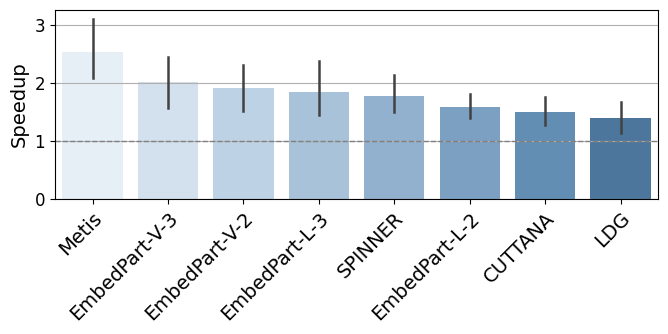

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    "EmbedPart-V-3": "#1f77b4",
    "EmbedPart-L-2": "#ff7f0e",
    "EmbedPart-V-2": "#2ca02c",
    "EmbedPart-L-3": "#d62728",
    "Metis": "#9467bd",
    "LDG": "#8c564b",
    "SPINNER": "#e377c2",
    "CUTTANA": "#dddddd"
}

# Sort globally by MEAN speedup (important change)
means = (
    epoch_times.groupby("partitioner")["speedup"]
    .mean()
    .sort_values(ascending=False)
)
order = means.index

print(means)

plt.figure(figsize=(7, 3.5))
ax = sns.barplot(
    data=epoch_times,
    x="partitioner",
    y="speedup",
    estimator="mean",
    errorbar=("ci", 95),
    order=order,
    palette=COLOURS[:len(sorted_partitioners)]  # safe slicing
)

plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)

plt.ylabel("Speedup", fontsize=14)
plt.xlabel("")
plt.xticks(rotation=45, ha="right", rotation_mode="anchor", fontsize=14)

plt.grid(axis="y")
plt.tight_layout()
plt.savefig(
    "plots/distributed/all_graphs_speedup_barplot.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [75]:
import pandas as pd


our_methods = ["EmbedPart-V-3", "EmbedPart-L-2", "EmbedPart-V-2", "EmbedPart-L-3"]
baselines = ["Metis", "LDG", "SPINNER"]  
group_keys = ["graph_name", "num_layers", "num_parts"]  
aggfunc = "mean"  


df_agg = (epoch_times
          .groupby(group_keys + ["partitioner"], as_index=False)["speedup"]
          .agg(aggfunc))

wins = {(m, b): 0 for m in our_methods for b in baselines}
totals = {(m, b): 0 for m in our_methods for b in baselines}

for _, sub in df_agg.groupby(group_keys):
    sp = sub.set_index("partitioner")["speedup"]

    for m in our_methods:
        if m not in sp:
            continue
        for b in baselines:
            if b not in sp:
                continue
            totals[(m, b)] += 1
            if sp[m] > sp[b]:              
                wins[(m, b)] += 1


pct = pd.DataFrame(
    {
        b: [ (100 * wins[(m, b)] / totals[(m, b)]) if totals[(m, b)] else float("nan")
             for m in our_methods ]
        for b in baselines
    },
    index=our_methods
).round(1)

print("Wins % of our methods vs baselines (rows=method, cols=baseline):")
print(pct)

counts = pd.DataFrame(
    {
        b: [ f"{wins[(m, b)]}/{totals[(m, b)]}" if totals[(m, b)] else "0/0"
             for m in our_methods ]
        for b in baselines
    },
    index=our_methods
)
print("\nRaw counts (wins/total):")
print(counts)

for m in our_methods:
    if "Metis" in baselines and totals[(m, "Metis")] > 0:
        print(f"{m} is better than Metis in {pct.loc[m, 'Metis']}% of cases ({counts.loc[m, 'Metis']}).")
    if "LDG" in baselines and totals[(m, 'LDG')] > 0:
        print(f"{m} is better than LDG in {pct.loc[m, 'LDG']}% of cases ({counts.loc[m, 'LDG']}).")

Win % of our methods vs baselines (rows=method, cols=baseline):
               Metis   LDG  SPINNER
EmbedPart-V-3   25.0  75.0     50.0
EmbedPart-L-2    0.0  68.8     25.0
EmbedPart-V-2   18.8  62.5     50.0
EmbedPart-L-3    6.2  75.0     43.8

Raw counts (wins/total):
              Metis    LDG SPINNER
EmbedPart-V-3  4/16  12/16    8/16
EmbedPart-L-2  0/16  11/16    4/16
EmbedPart-V-2  3/16  10/16    8/16
EmbedPart-L-3  1/16  12/16    7/16
EmbedPart-V-3 is better than Metis in 25.0% of cases (4/16).
EmbedPart-V-3 is better than LDG in 75.0% of cases (12/16).
EmbedPart-L-2 is better than Metis in 0.0% of cases (0/16).
EmbedPart-L-2 is better than LDG in 68.8% of cases (11/16).
EmbedPart-V-2 is better than Metis in 18.8% of cases (3/16).
EmbedPart-V-2 is better than LDG in 62.5% of cases (10/16).
EmbedPart-L-3 is better than Metis in 6.2% of cases (1/16).
EmbedPart-L-3 is better than LDG in 75.0% of cases (12/16).


('ogbn-arxiv', 2.0)
The groups are [2, 4]
Max Value 2.4


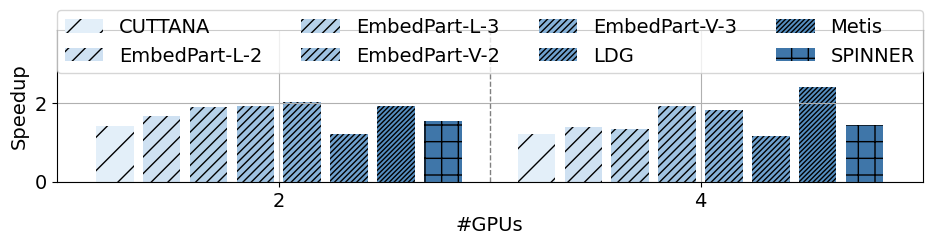

('ogbn-arxiv', 3.0)
The groups are [2, 4]
Max Value 2.05


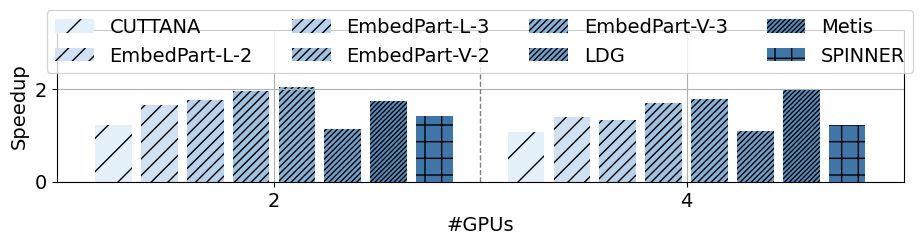

('ogbn-papers100M', 2.0)
The groups are [2, 4]
Max Value 3.88


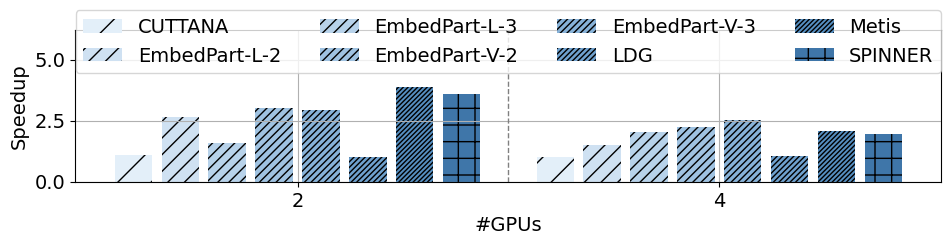

('ogbn-papers100M', 3.0)
The groups are [2, 4]
Max Value 3.23


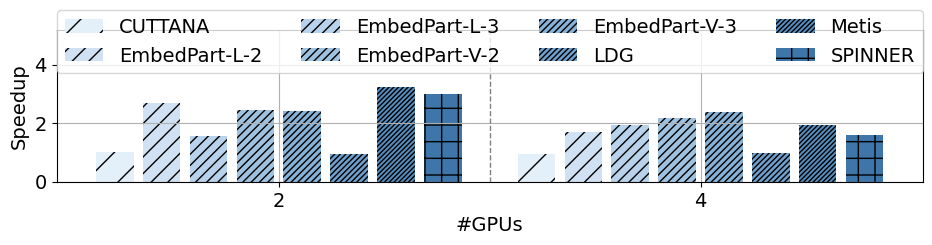

('ogbn-products', 2.0)
The groups are [2, 4]
Max Value 5.17


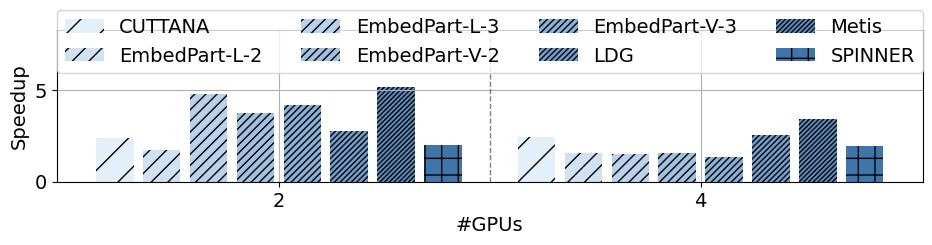

('ogbn-products', 3.0)
The groups are [2, 4]
Max Value 3.73


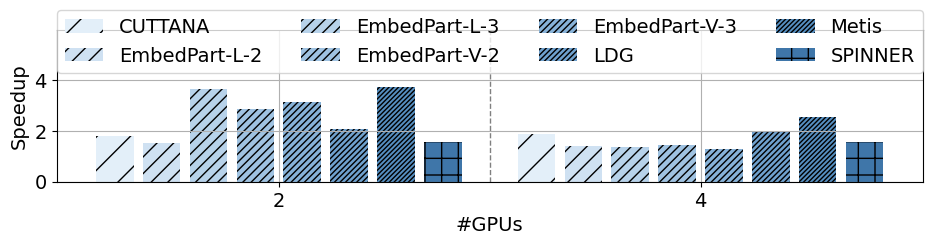

('reddit', 2.0)
The groups are [2, 4]
Max Value 2.14


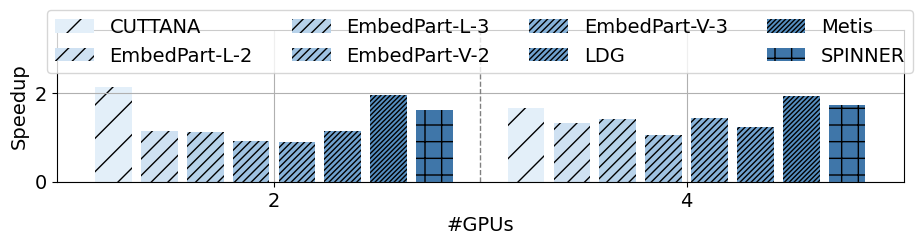

('reddit', 3.0)
The groups are [2, 4]
Max Value 1.44


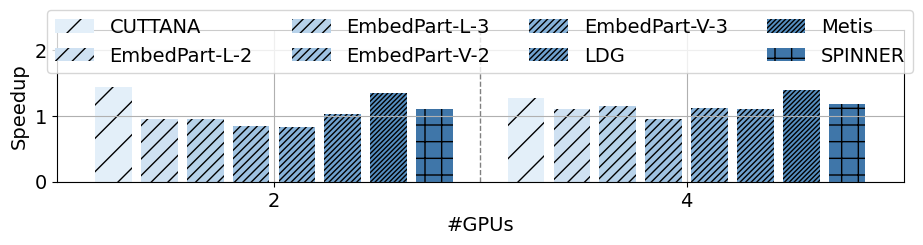

In [76]:
epoch_times["speedup"] = epoch_times["speedup"].round(2)
epoch_times["num_parts"] = epoch_times["num_parts"].astype(int)
for i, d in epoch_times.groupby(by=["graph_name", "num_layers"]):
    nested_dict = (
        d.groupby(['num_parts', 'partitioner'])['speedup']
        .apply(list)
        .unstack()
        .to_dict(orient='index')
    )
   # print(nested_dict)
    plt.rcParams["figure.figsize"] = (10,2.8)
    plt.rcParams.update({'font.size': 14})   # change 14 → your preferred size
    print(i)
    grouped_bar(nested_dict, numbers=False, xlabel="#GPUs", ylabel="Speedup", ncol=4,save=f"plots/distributed/{i[0]}-L{i[1]}",  bbox_to_anchor=(0.5, 1.2), factor_margin=1.6 )
    #def grouped_bar(group2classes2values, log=False, hline=None, xlabel=None, ylabel=None, numbers=False, save=None, bbox_to_anchor=(0.5, 1.30), y_lim=None, title=None, grid=None,ncol=8,legend=True, default_legend=False, factor_margin=1.0):

        
   # grouped_bar(nested_dict, numbers=False, xlabel="#GPUs", ylabel="Speedup", ncol=4,save=f"plots/distributed/{i[0]}-L{i[1]}", factor_margin=1.2 )
           

# 3. Graph Reordering

In [77]:

reordering_files = glob.glob("../results/single-node-training/2026-01-06_06-18-43/*") + glob.glob("../results/single-node-training/2026-01-07_12-10-36/*") + glob.glob("../results/single-node-training/2026-01-08_10-37-06/*")


def get_reordering_data(file_names):
    data = []
    for file_name in file_names: 
        with open(file_name, 'r') as file:
            json_obj = json.load(file)
            data.append(json_obj)    
    return pd.DataFrame(data)


572


In [78]:
reordering_df = get_reordering_data(reordering_files)


In [81]:

def find_partitiner(text):
    mapping = {
        "linkgraphsage.H64.L2": "\otwol{}",
       	"linkgraphsage.H64.L3":"\othreel{}",
        "graphsage.H64.L2":"\otwov{}",
       	"graphsage.H64.L3":"\othreev{}",
        "spinner": "\spinner{}",
        "metis": "\metis{}",
        "ldg": "\ldg{}",
        "random": "\random{}",
        "directed.cuttana.cuttana256": "\cuttana{}"
    }
    for k, v in mapping.items():
        if k in text:
            return v
    return text  # or some default value

def find_balance(text):
    mapping = {
        "TB1.05.VB1.1": "",
        "TB2048.0.VB2048.0": "-u"
    }
    for k, v in mapping.items():
        if k in text:
            return v
    return ""  # or some default value

def find_partitions(text):
    mapping = {
        ".P32": 32,
    }
    for k, v in mapping.items():
        if k in text:
            return v
    return -1  # or some default value

def find_graph(text):
    mapping = {
        "reddit": "reddit",
        "products": "products",
        "arxiv": "arxiv",
        "papers100M": "papers100M",
    }
    for k, v in mapping.items():
        if k in text:
            return v
    return False  # or some default value

    
    
reordering_df["partitioner"] = reordering_df["absolute_path_dgl_graph"].apply(find_partitiner)
reordering_df["num_partitions"] = reordering_df["absolute_path_dgl_graph"].apply(find_partitions)
reordering_df["balanced"] = reordering_df["absolute_path_dgl_graph"].apply(find_balance)
reordering_df["graph"] = reordering_df["absolute_path_dgl_graph"].apply(find_graph)


# Split into baseline (random) and others
df_rand = reordering_df[reordering_df["partitioner"] == "\random{}"].copy()
df_rand = df_rand[["graph","mode", "epoch_times_mean_after5", "test_time"]]
df_rand = df_rand.groupby(by=["graph", "mode"], as_index=False).mean()
df_others = reordering_df[reordering_df["partitioner"] != "\random{}"].copy()

print(len(df_rand), len(df_others))
# Join back on graph (and maybe other config columns if needed, like model, hidden_dim, etc.)
merged = df_others.merge(
    df_rand[["graph","mode", "epoch_times_mean_after5", "test_time"]].rename(columns={"epoch_times_mean_after5": "epoch_time_random", "test_time": "test_time_random"}),
    on=["graph","mode"],
    how="inner"
)

# Compute speedup
merged["speedup"] = merged["epoch_time_random"] / merged["epoch_times_mean_after5"]
merged["test_time_speedup"] = merged["test_time_random"] / merged["test_time"]


final_df = merged

final_df["partitioner"]  = final_df["partitioner"].astype(str)  + final_df["balanced"].astype(str)
final_df["graph"]  = final_df["graph"].astype(str)  + "_" + final_df["mode"].astype(str)




df_paper = final_df[final_df.num_partitions == 32]




7 528


## Training speedup 

In [87]:


table = df_paper.pivot_table(
    index="partitioner", 
    columns="graph", 
    values="speedup", 
    aggfunc="mean"
)
print(table.columns)

order = [
    'arxiv_cpu', 
    'products_cpu',
    'reddit_cpu', 
    'papers100M_cpu',
    'arxiv_cuda', 
    'products_cuda',
    'reddit_cuda',
]



table = table[order].round(3)   

def bold_max(s):
    max_val = s.max()
    out = []
    for v in s:
        if pd.isnull(v):
            out.append("-")
        elif v == max_val:
            out.append(f"\\textbf{{{v:.3f}}}")
        else:
            out.append(f"{v:.3f}")
    return out

formatted = table.apply(bold_max, axis=0, result_type="expand")
formatted.index = table.index
formatted.columns = table.columns
formatted["papers100M_cuda"] = "OOM"

latex_str = formatted.to_latex(escape=False, na_rep="-",
                               caption=f"Speedup by partitioner",
                               label=f"tab:speedup")

print(latex_str)

Index(['arxiv_cpu', 'arxiv_cuda', 'papers100M_cpu', 'products_cpu',
       'products_cuda', 'reddit_cpu', 'reddit_cuda'],
      dtype='object', name='graph')
\begin{table}
\centering
\caption{Speedup by partitioner}
\label{tab:speedup}
\begin{tabular}{lllllllll}
\toprule
graph &       arxiv_cpu &    products_cpu &      reddit_cpu &  papers100M_cpu &      arxiv_cuda &   products_cuda &     reddit_cuda & papers100M_cuda \\
partitioner  &                 &                 &                 &                 &                 &                 &                 &                 \\
\midrule
\cuttana{}   &           1.029 &           1.149 &           1.110 &           0.951 &           1.001 &           2.052 &  \textbf{1.026} &             OOM \\
\ldg{}       &           1.037 &           1.127 &           1.145 &  \textbf{1.022} &  \textbf{1.002} &           2.021 &           1.007 &             OOM \\
\metis{}     &           0.989 &           1.161 &           1.175 &           0.935 &

/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/3914526875.py:41: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_str = formatted.to_latex(escape=False, na_rep="-",


## Reordering metrics

In [89]:
reordering_files_metrics = glob.glob("../results/reordering-metrics/2025-09-24_16-42-23/*") + glob.glob("../results/reordering-metrics/2026-01-05_14-48-48/*") 


def get_reordering_metrics(file_names):
    data = []
    for file_name in file_names: 
        with open(file_name, 'r') as file:
            json_obj = json.load(file)
            data.append(json_obj)    
    return pd.DataFrame(data)

df_reordering_metrics = get_reordering_metrics(reordering_files_metrics)

df_reordering_metrics["partitioner"] = df_reordering_metrics["absolute_path"].apply(find_partitiner)
df_reordering_metrics["num_partitions"] = df_reordering_metrics["absolute_path"].apply(find_partitions)
df_reordering_metrics["balanced"] = df_reordering_metrics["absolute_path"].apply(find_balance)
df_reordering_metrics["graph"] = df_reordering_metrics["absolute_path"].apply(find_graph)


df_reordering_metrics["partitioner"]  = df_reordering_metrics["partitioner"].astype(str)  + df_reordering_metrics["balanced"].astype(str)





In [90]:
df_paper = df_reordering_metrics[df_reordering_metrics.num_partitions == 32]
df_paper = df_paper[~df_paper.partitioner.isin(["\ldg{}", "\spinner{}", "\random{}", "\metis{}","CUTTANA" ])]

#print(df_paper.head())
table = df_paper.pivot_table(
    index="partitioner", 
    columns="graph", 
    #values="avg_gap", 
    values="avg_bandwidth", 
    aggfunc="mean"
)
print(table.columns)

order = [
    'arxiv', 
    'products',
    'reddit', 
    'papers100M',

]



table = table[order].round(3)   # reorder columns if needed

 #Format with bold for max per row
def bold_max(s):
    max_val = s.min()
    out = []
    for v in s:
        if pd.isnull(v):
            out.append("-")
        elif v == max_val:
#            out.append(f"\\textbf{{{v:.3f}}}")
            out.append(f"{v/1000:.0f}K")
        else:
            out.append(f"{v/1000:.0f}K")
    return out

formatted = table.apply(bold_max, axis=0, result_type="expand")
formatted.index = table.index
formatted.columns = table.columns

latex_str = formatted.to_latex(escape=False, na_rep="-",
                               caption=f"Speedup by partitioner",
                               label=f"tab:speedup")
print(latex_str)


Index(['arxiv', 'papers100M', 'products', 'reddit'], dtype='object', name='graph')
\begin{table}
\centering
\caption{Speedup by partitioner}
\label{tab:speedup}
\begin{tabular}{lllll}
\toprule
graph & arxiv & products & reddit & papers100M \\
partitioner  &       &          &        &            \\
\midrule
\cuttana{}   &   76K &     925K &   150K &     64054K \\
\othreel{}   &   74K &    1022K &   154K &     57594K \\
\othreel{}-u &   56K &     659K &   124K &     38407K \\
\othreev{}   &   79K &    1196K &   151K &     61468K \\
\othreev{}-u &   72K &     875K &   123K &     44247K \\
\otwol{}     &   71K &    1025K &   154K &     55970K \\
\otwol{}-u   &   58K &     765K &   129K &     39413K \\
\otwov{}     &   79K &    1124K &   155K &     61169K \\
\otwov{}-u   &   72K &     925K &   131K &     44830K \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/3066348680.py:44: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_str = formatted.to_latex(escape=False, na_rep="-",


## edge-cut

In [91]:
file_names = glob.glob("../results/partitioning-metrics-fast/2025-09-23_14-34-57/*.json") 
file_names += glob.glob("../results/partitioning-metrics-fast/2025-09-17_18-58-17/*.json") # 50 epochs

def get_reordering_balancing(file_names):
    data = []
    for file_name in file_names: 
        with open(file_name, 'r') as file:
            json_obj = json.load(file)
            if not "partitioner" in json_obj:
                json_obj["partitioner"] = json_obj["strategy"]
            if "graph_name" in json_obj:
                json_obj["graph"] = json_obj["graph_name"]
            data.append(json_obj)    
    df_python = pd.DataFrame(data)
    return df_python

df = get_reordering_balancing(file_names)
df = df[df.num_parts.isin([32])]
df = df[df.graph.isin(['ogbn-papers100M', 'ogbn-products', 'reddit', 'ogbn-arxiv'])]

In [92]:
df["unlabanced"] = df["max_training_balance"] > 2

In [93]:
df["reordering"] = df["model_name"].astype(str) + "-" + df["num_layers"].astype(str)  + "-" +  df["unlabanced"].astype(str) 

df["reordering"] = df["reordering"].replace({
    "graphsage-2-False": "\otwov{}", 
    "graphsage-3-False": "\othreev{}", 
    "graphsage-2-True": "\otwov{}-u", 
    "graphsage-3-True": "\othreev{}-u", 
    "linkgraphsage-2-False": "\otwol{}", 
    "linkgraphsage-3-False": "\othreel{}", 
    "linkgraphsage-2-True": "\otwol{}-u", 
    "linkgraphsage-3-True": "\othreel{}-u", 
    
    
})

In [94]:


#print(df_paper.head())
table = df.pivot_table(
    index="reordering", 
    columns="graph", 
    #values="avg_gap", 
   # values="partitioning_time", 
    values="edge_cut", 
    aggfunc="mean"
)
print(table.columns)

order = [
    'ogbn-arxiv', 
    'ogbn-products',
    'reddit', 
    'ogbn-papers100M',

]



table = table[order].round(3)   # reorder columns if needed

 #Format with bold for max per row
def bold_max(s):
    max_val = s.min()
    out = []
    for v in s:
        if pd.isnull(v):
            out.append("-")
        elif v == max_val:
#            out.append(f"\\textbf{{{v:.3f}}}")
            out.append(f"{v:.3f}")
        else:
            out.append(f"{v:.3f}")
    return out

formatted = table.apply(bold_max, axis=0, result_type="expand")
formatted.index = table.index
formatted.columns = table.columns

latex_str = formatted.to_latex(escape=False, na_rep="-",
                               caption=f"Speedup by partitioner",
                               label=f"tab:speedup")
print(latex_str)


Index(['ogbn-arxiv', 'ogbn-papers100M', 'ogbn-products', 'reddit'], dtype='object', name='graph')
\begin{table}
\centering
\caption{Speedup by partitioner}
\label{tab:speedup}
\begin{tabular}{lllll}
\toprule
graph & ogbn-arxiv & ogbn-products & reddit & ogbn-papers100M \\
reordering   &            &               &        &                 \\
\midrule
\othreel{}   &      0.471 &         0.233 &  0.477 &           0.564 \\
\othreel{}-u &      0.360 &         0.162 &  0.372 &           0.286 \\
\othreev{}   &      0.680 &         0.357 &  0.401 &           0.716 \\
\othreev{}-u &      0.619 &         0.269 &  0.293 &           0.271 \\
\otwol{}     &      0.470 &         0.233 &  0.459 &           0.504 \\
\otwol{}-u   &      0.356 &         0.168 &  0.376 &           0.307 \\
\otwov{}     &      0.694 &         0.362 &  0.439 &           0.713 \\
\otwov{}-u   &      0.647 &         0.313 &  0.331 &           0.311 \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/660294570.py:42: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_str = formatted.to_latex(escape=False, na_rep="-",


In [95]:


#print(df_paper.head())
table = df.pivot_table(
    index="reordering", 
    columns="graph", 
    #values="avg_gap", 
    values="partitioning_time", 
    #values="edge_cut", 
    aggfunc="mean"
)
print(table.columns)

order = [
    'ogbn-arxiv', 
    'ogbn-products',
    'reddit', 
    'ogbn-papers100M',

]



table = table[order].round(3)   # reorder columns if needed

 #Format with bold for max per row
def bold_max(s):
    max_val = s.min()
    out = []
    for v in s:
        if pd.isnull(v):
            out.append("-")
        elif v == max_val:
#            out.append(f"\\textbf{{{v:.3f}}}")
            out.append(f"{v:.3f}")
        else:
            out.append(f"{v:.3f}")
    return out

formatted = table.apply(bold_max, axis=0, result_type="expand")
formatted.index = table.index
formatted.columns = table.columns

latex_str = formatted.to_latex(escape=False, na_rep="-",
                               caption=f"Speedup by partitioner",
                               label=f"tab:speedup")
print(latex_str)


Index(['ogbn-arxiv', 'ogbn-papers100M', 'ogbn-products', 'reddit'], dtype='object', name='graph')
\begin{table}
\centering
\caption{Speedup by partitioner}
\label{tab:speedup}
\begin{tabular}{lllll}
\toprule
graph & ogbn-arxiv & ogbn-products & reddit & ogbn-papers100M \\
reordering   &            &               &        &                 \\
\midrule
\othreel{}   &      0.081 &         0.308 &  0.093 &          15.577 \\
\othreel{}-u &      0.081 &         0.384 &  0.103 &           7.832 \\
\othreev{}   &      0.085 &         0.336 &  0.097 &          19.606 \\
\othreev{}-u &      0.085 &         0.402 &  0.113 &          10.788 \\
\otwol{}     &      0.085 &         0.313 &  0.099 &          15.121 \\
\otwol{}-u   &      0.081 &         0.395 &  0.103 &           7.891 \\
\otwov{}     &      0.084 &         0.358 &  0.097 &          19.938 \\
\otwov{}-u   &      0.077 &         0.409 &  0.115 &          10.717 \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/kk/7pm_3lhj6dzb_8z55dm9mwzm0000gn/T/ipykernel_16822/133619450.py:42: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_str = formatted.to_latex(escape=False, na_rep="-",
